<a href="https://colab.research.google.com/github/Lavesh789/Sales_forecasting_app/blob/main/salesforecasting_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

!pip install -q openpyxl scikit-learn seaborn matplotlib

Saving Sales_Forcasting_Dataset.xlsx to Sales_Forcasting_Dataset.xlsx


EDA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('Sales_Forcasting_Dataset.xlsx')
df['Date'] = pd.to_datetime(df['Date'])
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2971 entries, 0 to 2970
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Row_ID               2971 non-null   int64         
 1   Date                 2971 non-null   datetime64[ns]
 2   Product_ID           2971 non-null   object        
 3   Product_Name         2971 non-null   object        
 4   Category             2971 non-null   object        
 5   Store_ID             2971 non-null   object        
 6   Store_Location       2971 non-null   object        
 7   Units_Sold           2971 non-null   int64         
 8   Price                2971 non-null   float64       
 9   Discount_Percentage  2971 non-null   int64         
 10  Revenue              2971 non-null   float64       
 11  Promotion_Flag       2971 non-null   int64         
 12  Stock_Availability   2971 non-null   int64         
 13  Day_of_Week          2971 non-nul

,0
Row_ID,0
Date,0
Product_ID,0
Product_Name,0
Category,0
Store_ID,0
Store_Location,0
Units_Sold,0
Price,0
Discount_Percentage,0


In [3]:
df.tail()

,Row_ID,Date,Product_ID,Product_Name,Category,Store_ID,Store_Location,Units_Sold,Price,Discount_Percentage,...,Holiday_Name,Is_Weekend,Season,Weather,Local_Event_Flag,Competitor_Price,Economic_Indicator,Sales_Channel,Customer_Segment,Marketing_Spend
2966,2967,2026-08-26,P003,Office Chair,Furniture,S03,Mumbai,10,1903.934919,8,...,NaN,1,Autumn,Stormy,0,1798.918430,107.340955,Online,Retail,3321.039959
2967,2968,2026-08-27,P008,Coffee Maker,Appliances,S04,Delhi,95,2791.607918,15,...,NaN,1,Autumn,Clear,0,3010.983584,107.616883,In-Store,Wholesale,1987.494345
2968,2969,2026-08-28,P005,LED Desk Lamp,Home,S04,Delhi,70,677.845387,1,...,NaN,0,Autumn,Cloudy,0,733.086246,108.051096,Online,Retail,2899.864041
2969,2970,2026-08-29,P004,Notebook Pack,Stationery,S01,Chennai,3,4962.085887,10,...,NaN,0,Autumn,Clear,0,5140.309940,108.287405,Online,Corporate,7019.790342
2970,2971,2026-08-31,P008,Coffee Maker,Appliances,S04,Delhi,1,2482.274651,6,...,NaN,0,Autumn,Stormy,0,2615.246084,106.755435,Wholesale,Retail,4938.908172


In [4]:
print(df['Quarter'].unique())

['Q1' 'Q2' 'Q3' 'Q4']


In [5]:
print(df['Product_Name'].unique())

['Bluetooth Speaker' 'LED Desk Lamp' 'Running Shoes' 'Notebook Pack'
 'Wireless Mouse' 'Yoga Mat' 'Coffee Maker' 'Office Chair']


In [7]:
print(df['Store_Location'].unique())

['Chennai' 'Delhi' 'Bengaluru' 'Mumbai']


In [6]:
print(df['Season'].unique())

['Winter' 'Spring' 'Summer' 'Autumn']


In [8]:
print(df['Sales_Channel'].unique())

['Online' 'In-Store' 'Wholesale']


In [10]:
print(df['Customer_Segment'].unique())

['Retail' 'Corporate' 'Wholesale']


In [9]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['Date'].duplicated().sum()

np.int64(1919)

In [12]:
df['Row_ID'].duplicated().sum()

np.int64(0)

In [13]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nSummary stats:\n", df.describe())

Shape: (2971, 27)

Missing values:
 Holiday_Name    2940
dtype: int64

Summary stats:
            Row_ID                           Date   Units_Sold        Price  \
count  2971.00000                           2971  2971.000000  2971.000000   
mean   1486.00000  2024-12-19 13:54:37.684281344    42.117805  2569.785939   
min       1.00000            2023-01-06 00:00:00     0.000000   201.882929   
25%     743.50000            2024-06-08 00:00:00    15.000000  1286.524933   
50%    1486.00000            2024-12-17 00:00:00    43.000000  2542.812539   
75%    2228.50000            2025-07-12 00:00:00    64.000000  3768.773898   
max    2971.00000            2026-08-31 00:00:00   121.000000  4995.614847   
std     857.79815                            NaN    29.264835  1394.232596   

       Discount_Percentage        Revenue  Promotion_Flag  Stock_Availability  \
count          2971.000000    2971.000000     2971.000000         2971.000000   
mean              7.886570   93244.069538       

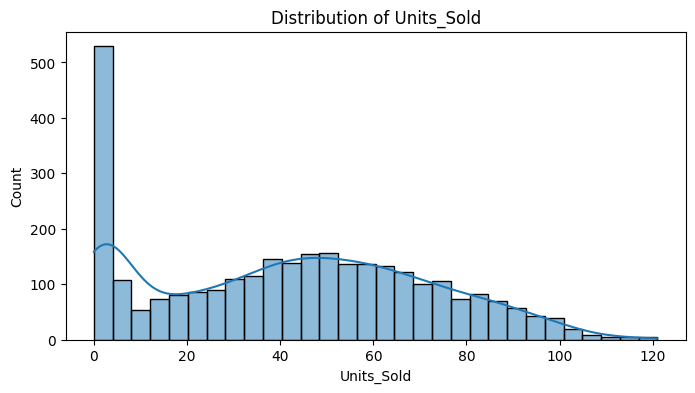

In [14]:
# Units_Sold distribution
plt.figure(figsize=(8,4))
sns.histplot(df['Units_Sold'], bins=30, kde=True)
plt.title('Distribution of Units_Sold')
plt.show()

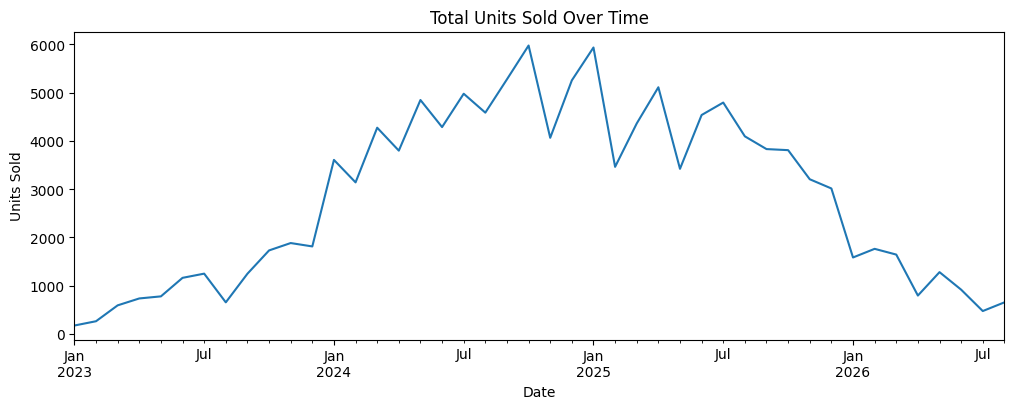

In [15]:
# Trend over time
monthly = df.groupby(df['Date'].dt.to_period('M'))['Units_Sold'].sum()
plt.figure(figsize=(12,4))
monthly.plot()
plt.title('Total Units Sold Over Time')
plt.ylabel('Units Sold')
plt.show()

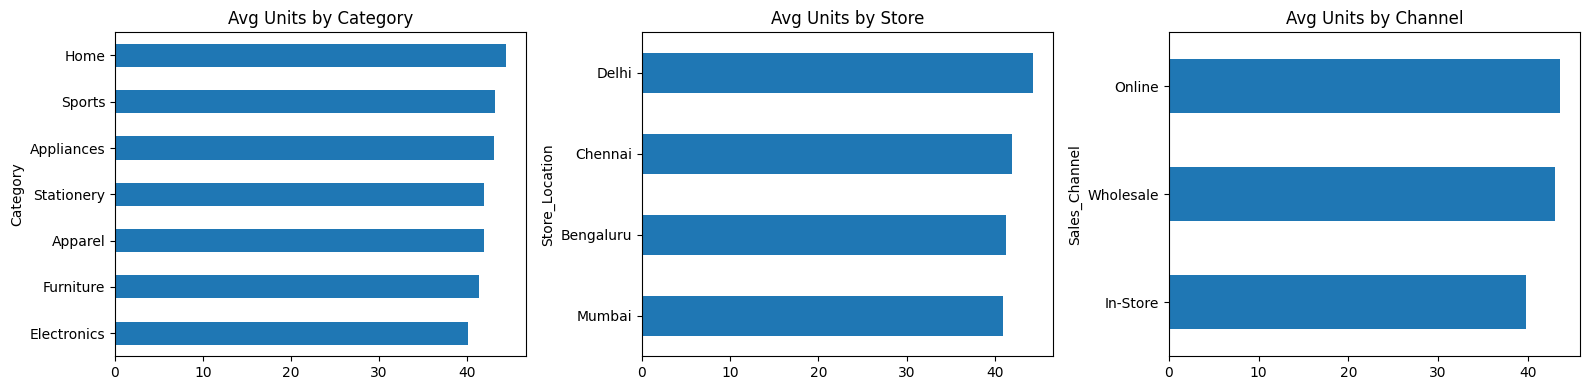

In [16]:
# Units sold by category / store / channel
fig, axes = plt.subplots(1, 3, figsize=(16,4))
df.groupby('Category')['Units_Sold'].mean().sort_values().plot(kind='barh', ax=axes[0], title='Avg Units by Category')
df.groupby('Store_Location')['Units_Sold'].mean().sort_values().plot(kind='barh', ax=axes[1], title='Avg Units by Store')
df.groupby('Sales_Channel')['Units_Sold'].mean().sort_values().plot(kind='barh', ax=axes[2], title='Avg Units by Channel')
plt.tight_layout()
plt.show()

In [17]:
# Correlation with target
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['Row_ID'])
corr_with_target = numeric_df.corr()['Units_Sold'].sort_values(ascending=False)
print("\nCorrelation with Units_Sold:\n", corr_with_target)


Correlation with Units_Sold:
 Units_Sold             1.000000
Stock_Availability     0.693694
Revenue                0.578733
Discount_Percentage    0.418321
Promotion_Flag         0.383061
Marketing_Spend        0.267695
Is_Weekend             0.213506
Local_Event_Flag       0.152730
Holiday_Flag           0.041700
Economic_Indicator    -0.025366
Price                 -0.306923
Competitor_Price      -0.309210
Name: Units_Sold, dtype: float64


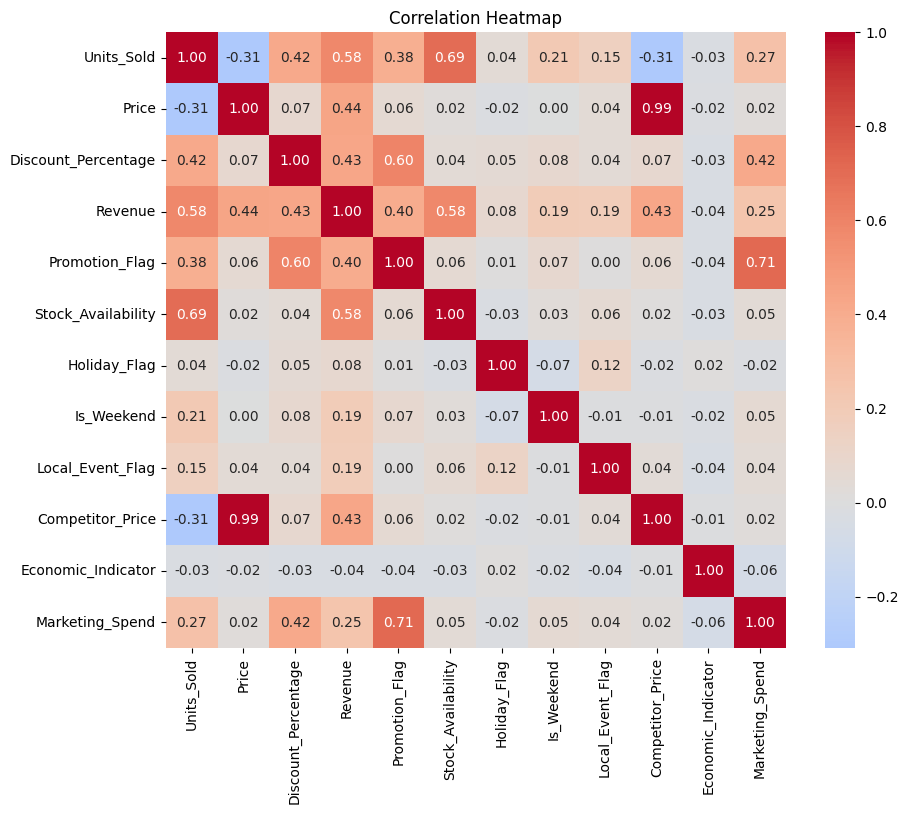

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

Feature Importance

Top 15 features driving Units_Sold:
 Stock_Availability            0.480616
Discount_Percentage           0.191751
Price                         0.106557
Competitor_Price              0.089939
Promotion_Flag                0.029191
Marketing_Spend               0.016739
Is_Weekend                    0.011324
Local_Event_Flag              0.011271
Economic_Indicator            0.009042
Holiday_Flag                  0.004680
Day_of_Week_Saturday          0.003098
Weather_Clear                 0.001848
Customer_Segment_Wholesale    0.001584
Day_of_Week_Wednesday         0.001546
Month_September               0.001480
dtype: float64


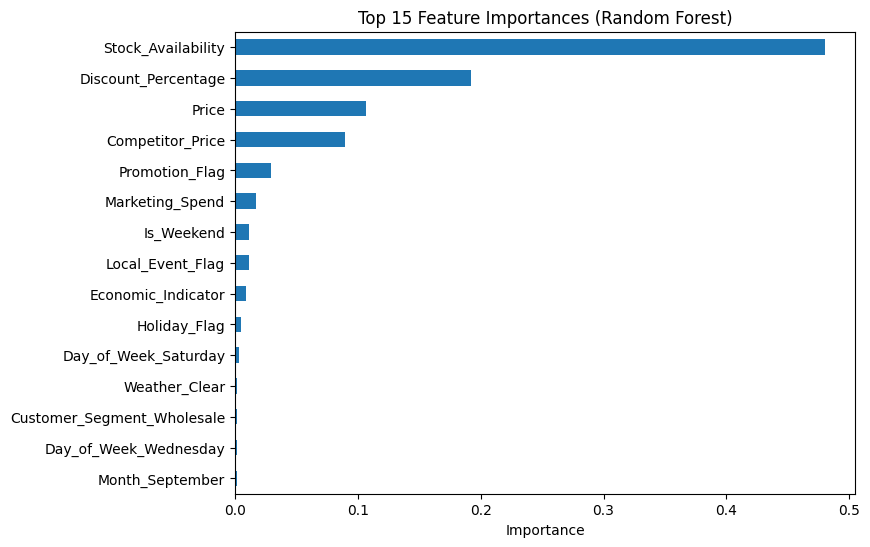

In [19]:
!pip install -q xgboost
!pip install lightgbm
!pip install scikit-learn
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor

target = 'Units_Sold'
drop_cols = ['Row_ID', 'Date', 'Units_Sold', 'Revenue', 'Holiday_Name']
X = df.drop(columns=drop_cols)
y = df[target]

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
], remainder='passthrough')

rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('rf', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X, y)

ohe = rf_pipeline.named_steps['prep'].named_transformers_['cat']
feat_names = list(ohe.get_feature_names_out(cat_cols)) + num_cols
importances = pd.Series(rf_pipeline.named_steps['rf'].feature_importances_, index=feat_names)
importances = importances.sort_values(ascending=False)

print("Top 15 features driving Units_Sold:\n", importances.head(15))

plt.figure(figsize=(8,6))
importances.head(15).sort_values().plot(kind='barh')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.show()

In [20]:
print('numpy', np.__version__)
print('pandas', pd.__version__)
print('sklearn', sklearn.__version__)

numpy 2.1.3
pandas 2.2.3
sklearn 1.6.1


Build the Forecasting/Predictive Model

In [21]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)

    # MAPE: skip weeks where actual = 0 (division by zero is undefined,
    # not a model failure) — report how many were excluded
    nonzero = y_true != 0
    mape = np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100 if nonzero.sum() > 0 else np.nan

    eps = 1e-6
    smape = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)) * 100

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    return {
        "MAE": mae, "MSE": mse, "RMSE": rmse,
        "MAPE": mape, "SMAPE": smape, "R2": r2,
    }

results = []

In [22]:
!pip install sktime
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sktime.performance_metrics.forecasting import mean_absolute_percentage_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Random Forest': Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))]),
    'XGBoost': Pipeline([('prep', preprocessor),('model', XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,subsample=0.8, colsample_bytree=0.8,random_state=42, n_jobs=-1))]),
    'Gradient Boosting': Pipeline([('prep', preprocessor),('model', GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42))]),
    "LightGBM": Pipeline([("prep", preprocessor),("model", LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1))]),
}

results = {}
fitted_models = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    '''results[name] = {
        'MAE': mean_absolute_error(y_test, pred),
        'MSE':mean_squared_error(y_test, pred),
        'RMSE': mean_squared_error(y_test, pred) ** 0.5,
        'MAPE': mean_absolute_percentage_error(y_test, pred, symmetric=False),
        'SMAPE': mean_absolute_percentage_error(y_test, pred, symmetric=True),
        'R2': r2_score(y_test, pred)
    }'''
    results[name] = evaluate_model(y_test, pred)
    fitted_models[name] = pipe

results_df = pd.DataFrame(results).T.sort_values('MAPE', ascending=False)
print(results_df)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 10.1 MB/s eta 0:00:00
                        MAE        MSE      RMSE       MAPE      SMAPE  \
Gradient Boosting  4.437777  37.323706  6.109313  27.511837  28.056146   
LightGBM           3.930187  30.179247  5.493564  27.113082  26.794087   
XGBoost            3.426052  23.229984  4.819749  22.580387  23.814438   
Random Forest      3.243261  21.601779  4.647771  18.949559  21.440749   

                         R2  
Gradient Boosting  0.955806  
LightGBM           0.964265  
XGBoost            0.972494  
Random Forest      0.974422  


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



 Best model: Random Forest (MAPE = 18.9496)


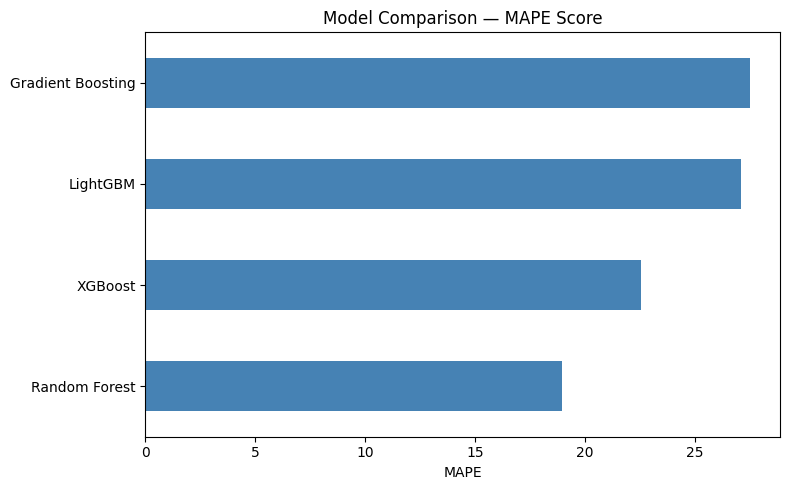

In [23]:
#Auto-select the best model
best_name = results_df['MAPE'].idxmin()
best_pipe = fitted_models[best_name]
print(f"\n Best model: {best_name} (MAPE = {results_df.loc[best_name, 'MAPE']:.4f})")

# Bar chart comparing all 4
plt.figure(figsize=(8,5))
results_df['MAPE'].sort_values().plot(kind='barh', color='steelblue')
plt.title('Model Comparison — MAPE Score')
plt.xlabel('MAPE')
plt.tight_layout()
plt.show()

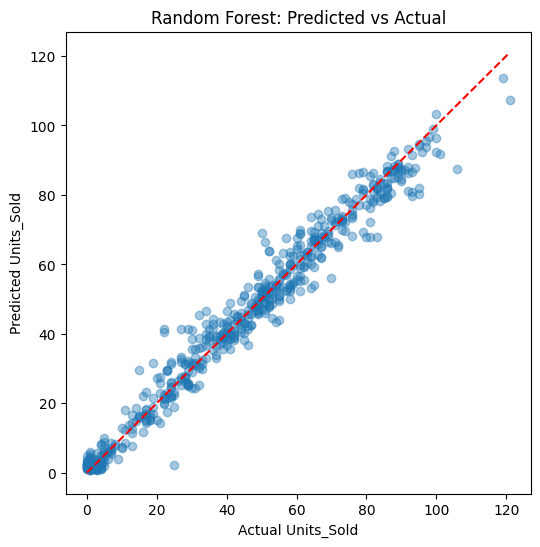

In [24]:
# Best model = Random Forest (typically). Plot predicted vs actual
best_pipe = models['Random Forest']
pred = best_pipe.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Units_Sold')
plt.ylabel('Predicted Units_Sold')
plt.title('Random Forest: Predicted vs Actual')
plt.show()

Combined Summary (EDA + Model insights together)

In [25]:
print("KEY INSIGHTS\n")
print("1. Top correlates of Units_Sold (linear):")
print(corr_with_target.drop('Units_Sold').head(5))

print("\n2. Top drivers (non-linear, Random Forest):")
print(importances.head(5))

print("\n3. Model performance:")
print(results_df)

print("\n4. Business takeaways:")
print("- Stock_Availability is the single biggest driver — stockouts are likely capping sales.")
print("- Discounting and promotions meaningfully lift Units_Sold.")
print("- Price and Competitor_Price move inversely with Units_Sold, as expected.")
print("- Economic_Indicator and Holiday_Flag have minimal individual predictive power here.")

KEY INSIGHTS

1. Top correlates of Units_Sold (linear):
Stock_Availability     0.693694
Revenue                0.578733
Discount_Percentage    0.418321
Promotion_Flag         0.383061
Marketing_Spend        0.267695
Name: Units_Sold, dtype: float64

2. Top drivers (non-linear, Random Forest):
Stock_Availability     0.480616
Discount_Percentage    0.191751
Price                  0.106557
Competitor_Price       0.089939
Promotion_Flag         0.029191
dtype: float64

3. Model performance:
                        MAE        MSE      RMSE       MAPE      SMAPE  \
Gradient Boosting  4.437777  37.323706  6.109313  27.511837  28.056146   
LightGBM           3.930187  30.179247  5.493564  27.113082  26.794087   
XGBoost            3.426052  23.229984  4.819749  22.580387  23.814438   
Random Forest      3.243261  21.601779  4.647771  18.949559  21.440749   

                         R2  
Gradient Boosting  0.955806  
LightGBM           0.964265  
XGBoost            0.972494  
Random Forest    

Feature Engineering

In [26]:
import pandas as pd
import numpy as np

df = df.sort_values(['Product_ID', 'Store_ID', 'Date']).reset_index(drop=True)

# Resample Daily Data into Weekly Aggregations (Ending on Sunday 'W-SUN')
"""weekly_df = (
    df.resample("W-SUN", on="Date")
    .agg(
        {
            "Units_Sold": "sum",  # Total weekly sales target
            "Price": "mean",  # Average weekly price
            "Discount_Percentage": "mean",  # Average weekly discount
            "Promotion_Flag": "max",  # Active promo during the week (1 if any promo occurred)
            "Product_ID": "first",
            "Category": "first",
            "Store_ID": "first",
        }
    )
    .reset_index()
)"""

df['Year'] = df['Date'].dt.year
df['Day'] = df['Date'].dt.day
df['DayOfYear'] = df['Date'].dt.dayofyear
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['Month_Num'] = df['Date'].dt.month
df['DayOfWeek_Num'] = df['Date'].dt.dayofweek

#Cyclical encoding (so Dec and Jan, or Sun and Mon, are "close" to a model)
df['Month_sin'] = np.sin(2 * np.pi * df['Month_Num'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month_Num'] / 12)
df['DOW_sin'] = np.sin(2 * np.pi * df['DayOfWeek_Num'] / 7)
df['DOW_cos'] = np.cos(2 * np.pi * df['DayOfWeek_Num'] / 7)

#Price-related features
df['Price_Diff_vs_Competitor'] = df['Price'] - df['Competitor_Price']
df['Price_Ratio_vs_Competitor'] = df['Price'] / df['Competitor_Price']
df['Discounted_Price'] = df['Price'] * (1 - df['Discount_Percentage'] / 100)
df['Discount_Amount'] = df['Price'] - df['Discounted_Price']

#Marketing efficiency
df['Marketing_Spend_per_Unit_Price'] = df['Marketing_Spend'] / df['Price']

#Interaction features (combined effects)
df['Promo_and_Weekend'] = df['Promotion_Flag'] * df['Is_Weekend']
df['Promo_and_Holiday'] = df['Promotion_Flag'] * df['Holiday_Flag']
df['InStock_and_Promo'] = df['Stock_Availability'] * df['Promotion_Flag']

#Lag & rolling features per Product + Store (time-series signal)
grp = df.groupby(['Product_ID', 'Store_ID'])
df['Units_Sold_Lag1'] = grp['Units_Sold'].shift(1)
df['Units_Sold_Lag7'] = grp['Units_Sold'].shift(7)
df['Units_Sold_RollMean_4'] = grp['Units_Sold'].transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean())
df['Units_Sold_RollStd_4']  = grp['Units_Sold'].transform(lambda x: x.shift(1).rolling(4, min_periods=1).std())

# Fill lag/rolling NaNs (first record(s) of each product/store group) with that group's mean
for c in ['Units_Sold_Lag1', 'Units_Sold_Lag7', 'Units_Sold_RollMean_4', 'Units_Sold_RollStd_4']:
    df[c] = df[c].fillna(grp['Units_Sold'].transform('mean'))

#Holiday flag consolidation
df['Has_Holiday_Name'] = df['Holiday_Name'].notna().astype(int)

print("New shape:", df.shape)
#print("New columns added:", df.shape[1] - 27)
df[['Date','Product_ID','Store_ID','Units_Sold','Units_Sold_Lag1','Units_Sold_Lag7','Units_Sold_RollMean_4']].head(10)

New shape: (2971, 50)


,Date,Product_ID,Store_ID,Units_Sold,Units_Sold_Lag1,Units_Sold_Lag7,Units_Sold_RollMean_4
0,2023-04-08,P001,S01,51,42.230159,42.230159,42.230159
1,2023-05-19,P001,S01,33,51.000000,42.230159,51.000000
2,2023-07-16,P001,S01,23,33.000000,42.230159,42.000000
3,2023-07-22,P001,S01,22,23.000000,42.230159,35.666667
4,2023-09-23,P001,S01,18,22.000000,42.230159,32.250000
5,2023-12-13,P001,S01,24,18.000000,42.230159,24.000000
6,2023-12-31,P001,S01,36,24.000000,42.230159,21.750000
7,2024-01-20,P001,S01,47,36.000000,51.000000,25.000000
8,2024-01-26,P001,S01,44,47.000000,33.000000,31.250000
9,2024-02-07,P001,S01,1,44.000000,23.000000,37.750000


In [27]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2971 entries, 0 to 2970
Data columns (total 50 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Row_ID                          2971 non-null   int64         
 1   Date                            2971 non-null   datetime64[ns]
 2   Product_ID                      2971 non-null   object        
 3   Product_Name                    2971 non-null   object        
 4   Category                        2971 non-null   object        
 5   Store_ID                        2971 non-null   object        
 6   Store_Location                  2971 non-null   object        
 7   Units_Sold                      2971 non-null   int64         
 8   Price                           2971 non-null   float64       
 9   Discount_Percentage             2971 non-null   int64         
 10  Revenue                         2971 non-null   float64       
 11  Prom

Total number of weekly rows

In [28]:
total_dates = len(df)
print(f"Total dates in dataset: {total_dates}")

Total dates in dataset: 2971


Evaluation Model

In [29]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)

    # MAPE: skip weeks where actual = 0 (division by zero is undefined,
    # not a model failure) — report how many were excluded
    nonzero = y_true != 0
    mape = np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100 if nonzero.sum() > 0 else np.nan

    eps = 1e-6
    smape = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)) * 100

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    return {
        "MAE": mae, "MSE": mse, "RMSE": rmse,
        "MAPE": mape, "SMAPE": smape, "R2": r2,
    }

results = []

Model with Engineered Features

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sktime.performance_metrics.forecasting import mean_absolute_percentage_error

target = 'Units_Sold'
# Drop identifiers/leakage, and raw Month_Num/DayOfWeek_Num (replaced by sin/cos versions)
drop_cols = ['Row_ID', 'Date', 'Units_Sold', 'Revenue', 'Holiday_Name', 'Month_Num', 'DayOfWeek_Num']
X = df.drop(columns=drop_cols)
y = df[target]

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
], remainder='passthrough')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Time-based Sequential Train/Test Split (80% Train, 20% Test on Weekly Data)
#split_idx = int(len(weekly_df) * 0.8)
#X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
#y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

models = {
    'Random Forest': Pipeline([('prep', preprocessor),('model', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))]),
    'XGBoost': Pipeline([('prep', preprocessor),('model', XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,subsample=0.8, colsample_bytree=0.8,random_state=42, n_jobs=-1))]),
    'Gradient Boosting': Pipeline([('prep', preprocessor),('model', GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42))]),
    'LightGBM': Pipeline([("prep", preprocessor),("model", LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1))]),
}

results = {}
fitted_pipelines = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    '''results[name] = {
        'MAE': mean_absolute_error(y_test, pred),
        'MSE': mean_squared_error(y_test, pred),
        'RMSE': mean_squared_error(y_test, pred) ** 0.5,
        'MAPE': mean_absolute_percentage_error(y_test, pred, symmetric=False),
        'SMAPE': mean_absolute_percentage_error(y_test, pred, symmetric=True),
        'R2': r2_score(y_test, pred)
    }'''
    results[name] = evaluate_model(y_test, pred)
    fitted_pipelines[name] = pipe
# Classical Time Series Model on Weekly Target
#ts_y = weekly_df.set_index("Date")["Units_Sold"]
#ts_train, ts_test = ts_y.iloc[:split_idx], ts_y.iloc[split_idx:]

results_df = pd.DataFrame(results).T.sort_values('MAPE', ascending=False)
print(results_df)

                        MAE        MSE      RMSE       MAPE      SMAPE  \
Gradient Boosting  4.830065  40.844942  6.391005  42.567815  32.485280   
LightGBM           4.379050  35.174279  5.930791  36.940165  30.293167   
XGBoost            4.189955  31.619271  5.623102  35.069279  29.979526   
Random Forest      4.181720  32.067782  5.662842  33.520781  29.567434   

                         R2  
Gradient Boosting  0.953443  
LightGBM           0.959907  
XGBoost            0.963959  
Random Forest      0.963448  


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



 Best model: Random Forest (MAPE = 33.5208)


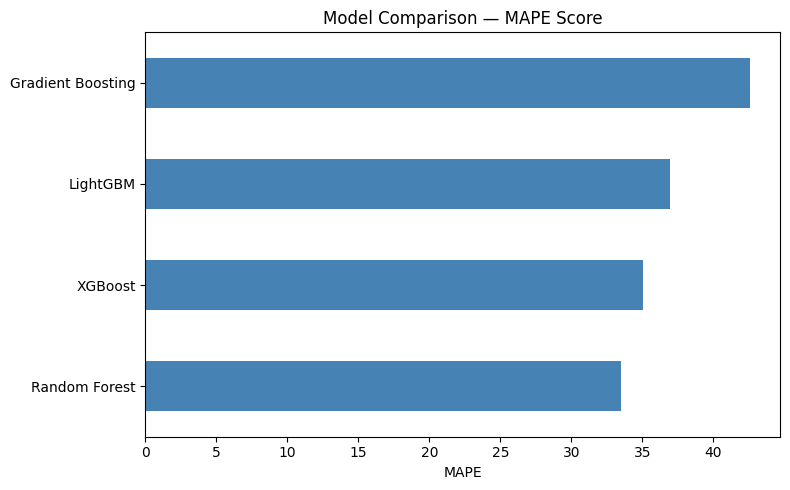

In [31]:
#Auto-select the best model
best_name = results_df['MAPE'].idxmin()
best_pipe = fitted_models[best_name]
print(f"\n Best model: {best_name} (MAPE = {results_df.loc[best_name, 'MAPE']:.4f})")

# Bar chart comparing all 4
plt.figure(figsize=(8,5))
results_df['MAPE'].sort_values().plot(kind='barh', color='steelblue')
plt.title('Model Comparison — MAPE Score')
plt.xlabel('MAPE')
plt.tight_layout()
plt.show()

In [32]:
# Refit feature importance on the richer feature set
best_pipe = models['Random Forest']
ohe = best_pipe.named_steps['prep'].named_transformers_['cat']
feat_names = list(ohe.get_feature_names_out(cat_cols)) + num_cols
importances = pd.Series(best_pipe.named_steps['model'].feature_importances_, index=feat_names).sort_values(ascending=False)
print("\nTop 15 features:\n", importances.head(15))


Top 15 features:
 InStock_and_Promo                 0.547487
Discounted_Price                  0.150956
Stock_Availability                0.099701
Discount_Percentage               0.051317
Competitor_Price                  0.032306
Price                             0.019644
Local_Event_Flag                  0.011702
Economic_Indicator                0.006029
Is_Weekend                        0.005772
Price_Ratio_vs_Competitor         0.004360
Promo_and_Weekend                 0.004291
Marketing_Spend_per_Unit_Price    0.004239
Discount_Amount                   0.003877
Price_Diff_vs_Competitor          0.003748
Marketing_Spend                   0.002948
dtype: float64


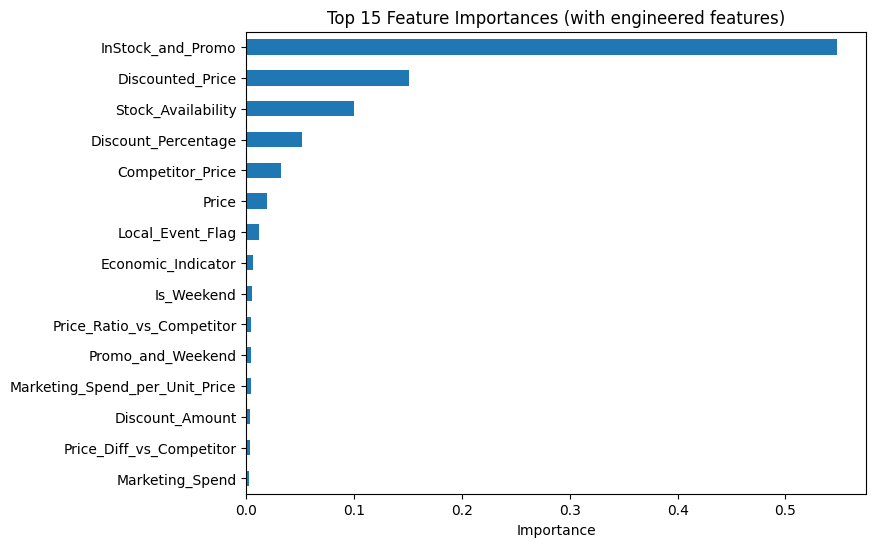

In [33]:
plt.figure(figsize=(8,6))
importances.head(15).sort_values().plot(kind='barh')
plt.title('Top 15 Feature Importances (with engineered features)')
plt.xlabel('Importance')
plt.show()

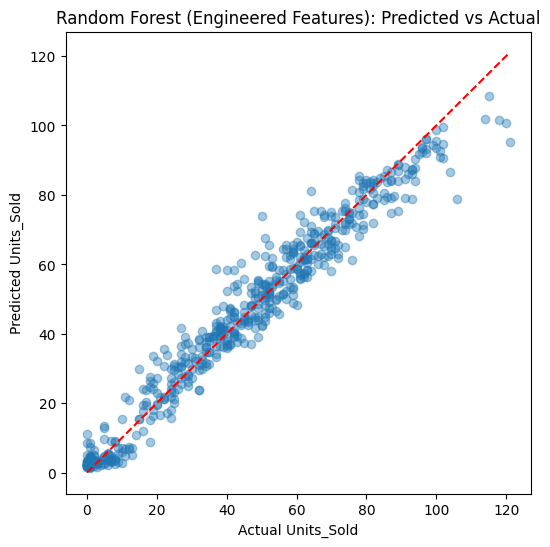

In [34]:
# Predicted vs actual
pred = best_pipe.predict(X_test)
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Units_Sold')
plt.ylabel('Predicted Units_Sold')
plt.title('Random Forest (Engineered Features): Predicted vs Actual')
plt.show()

Time-series Forecasting

dataset length: 1052
count    1052.000000
mean      118.946768
std        85.878540
min         0.000000
25%        56.000000
50%        97.000000
75%       168.000000
max       486.000000
Name: Units_Sold, dtype: float64


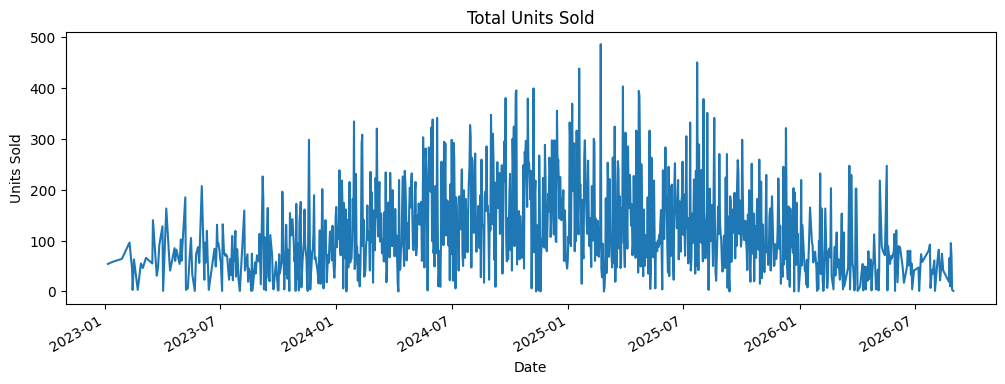

In [35]:
!pip install -q prophet statsmodels tensorflow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

df = pd.read_excel('Sales_Forcasting_Dataset.xlsx')
df['Date'] = pd.to_datetime(df['Date'])

# Aggregate to a single weekly time series (sum of Units_Sold across all
# products/stores) — ARIMA/Prophet/LSTM need one continuous series, not
# per-transaction rows. Missing weeks are filled with 0 (no recorded sales).
df = (
  df.groupby('Date')['Units_Sold']
  .sum()
)
df.index.name = 'Date'

print("dataset length:", len(df))
print(df.describe())

plt.figure(figsize=(12, 4))
df.plot()
plt.title('Total Units Sold')
plt.ylabel('Units Sold')
plt.show()

# Chronological train/test split (last 20% as test — standard for time series)
#test_size = int(len(weekly) * 0.2)
#train, test = weekly.iloc[:-test_size], weekly.iloc[-test_size:]
#print(f"Train: {len(train)} weeks | Test: {len(test)} weeks")
train, test = train_test_split(df, test_size=0.2, random_state=42)


Metrics Function

In [36]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)

    # MAPE: skip weeks where actual = 0 (division by zero is undefined,
    # not a model failure) — report how many were excluded
    nonzero = y_true != 0
    mape = np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100 if nonzero.sum() > 0 else np.nan

    eps = 1e-6
    smape = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)) * 100

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    return {
        "Model": model_name, "MAE": mae, "MSE": mse, "RMSE": rmse,
        "MAPE": mape, "SMAPE": smape, "R2": r2,
    }

results = []

Arima

In [37]:
from statsmodels.tsa.arima.model import ARIMA

try:
    arima_model = ARIMA(train, order=(2, 1, 2))
    arima_fit = arima_model.fit()
    arima_pred = arima_fit.forecast(steps=len(test))
    results.append(evaluate_model(test.values, arima_pred.values, "ARIMA"))
    print("ARIMA done.")
except Exception as e:
    print("ARIMA failed:", e)
    arima_pred = pd.Series(np.full(len(test), train.mean()), index=test.index)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsm

ARIMA done.


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


Prophet

In [38]:
from prophet import Prophet

try:
    prophet_train = train.reset_index()
    prophet_train.columns = ['ds', 'y']

    prophet_model = Prophet(weekly_seasonality=False, yearly_seasonality=True, daily_seasonality=True)
    prophet_model.fit(prophet_train)

    future = pd.DataFrame({'ds': test.index})
    forecast = prophet_model.predict(future)
    prophet_pred = forecast['yhat'].values
    prophet_pred = np.clip(prophet_pred, 0, None)  # sales can't be negative

    results.append(evaluate_model(test.values, prophet_pred, "Prophet"))
    print("Prophet done.")
except Exception as e:
    print("Prophet failed:", e)
    prophet_pred = np.full(len(test), train.mean())

Prophet done.


LSTM

In [39]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

try:
    tf.random.set_seed(42)

    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))

    WINDOW = 8  # use past 8 weeks to predict the next week
    def make_sequences(data, window):
        X, y = [], []
        for i in range(window, len(data)):
            X.append(data[i-window:i, 0])
            y.append(data[i, 0])
        return np.array(X), np.array(y)

    X_train, y_train = make_sequences(train_scaled, WINDOW)
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

    lstm_model = Sequential([
        LSTM(50, activation='relu', input_shape=(WINDOW, 1)),
        Dense(1)
    ])
    lstm_model.compile(optimizer='adam', loss='mse')
    lstm_model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=0)

    # Recursive forecast: walk forward one week at a time using the model's
    # own prior predictions once we run out of real history
    history = list(train_scaled.flatten()[-WINDOW:])
    lstm_preds_scaled = []
    for _ in range(len(test)):
        x_input = np.array(history[-WINDOW:]).reshape((1, WINDOW, 1))
        next_pred = lstm_model.predict(x_input, verbose=0)[0, 0]
        lstm_preds_scaled.append(next_pred)
        history.append(next_pred)

    lstm_pred = scaler.inverse_transform(np.array(lstm_preds_scaled).reshape(-1, 1)).flatten()
    lstm_pred = np.clip(lstm_pred, 0, None)

    results.append(evaluate_model(test.values, lstm_pred, "LSTM"))
    print("LSTM done.")
except Exception as e:
    print("LSTM failed:", e)
    lstm_pred = np.full(len(test), train.mean())

LSTM done.


Compare Models

               MAE          MSE       RMSE        MAPE      SMAPE        R2
Model                                                                      
ARIMA    67.826392  6806.835295  82.503547  273.316541  63.242485 -0.001369
Prophet  72.858667  7745.485603  88.008441  227.115254  68.587664 -0.139456
LSTM     67.872556  6786.963185  82.383027  274.770106  63.178603  0.001555


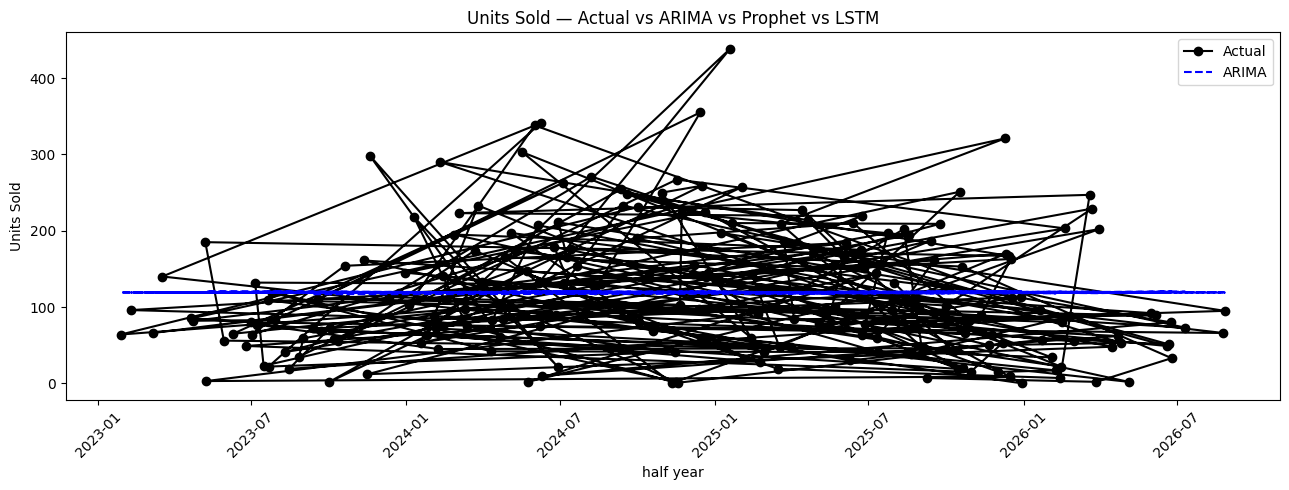


Best time-series model by RMSE: Prophet


In [40]:
results_df = pd.DataFrame(results).set_index("Model")
print(results_df)

plt.figure(figsize=(13, 5))
#plt.plot(train.index[-20:], train.values[-20:], label="Train (recent)", color="gray")
plt.plot(test.index, test.values, label="Actual", color="black", marker="o")
plt.plot(test.index, arima_pred, label="ARIMA", color="blue", linestyle="--")
#plt.plot(test.index, prophet_pred, label="Prophet", linestyle="--")
#plt.plot(test.index, lstm_pred, label="LSTM", linestyle="--")
plt.title("Units Sold — Actual vs ARIMA vs Prophet vs LSTM")
plt.xlabel("half year")
plt.ylabel("Units Sold")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

best_ts_model = results_df["MAPE"].idxmin()
print(f"\nBest time-series model by RMSE: {best_ts_model}")

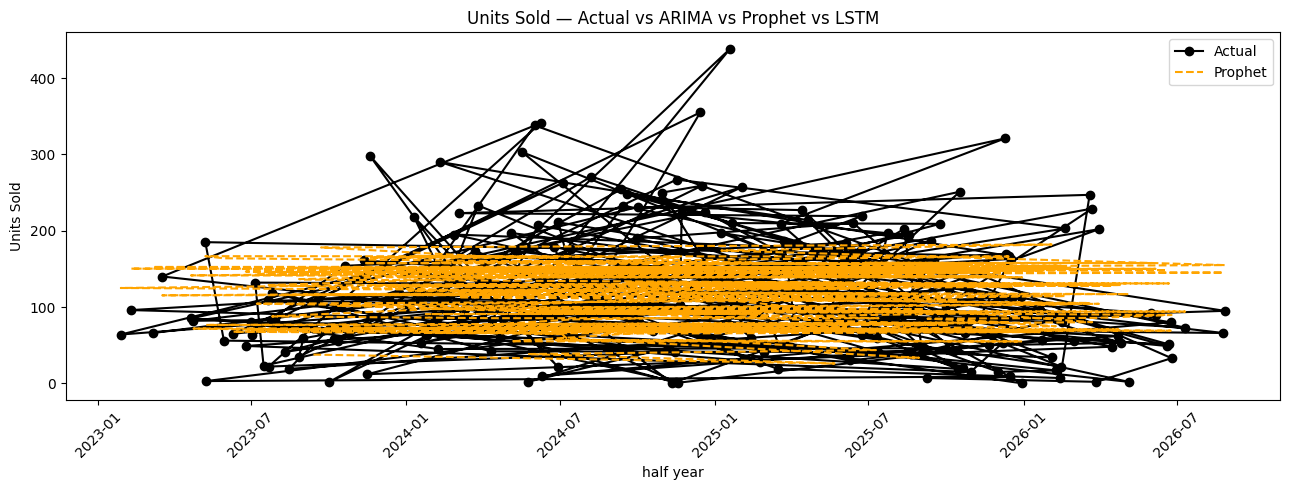

In [41]:
plt.figure(figsize=(13, 5))
#plt.plot(train.index[-20:], train.values[-20:], label="Train (recent)", color="gray")
plt.plot(test.index, test.values, label="Actual", color="black", marker="o")
#plt.plot(test.index, arima_pred, label="ARIMA", linestyle="--")
plt.plot(test.index, prophet_pred, label="Prophet", color="orange", linestyle="--")
#plt.plot(test.index, lstm_pred, label="LSTM", linestyle="--")
plt.title("Units Sold — Actual vs ARIMA vs Prophet vs LSTM")
plt.xlabel("half year")
plt.ylabel("Units Sold")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

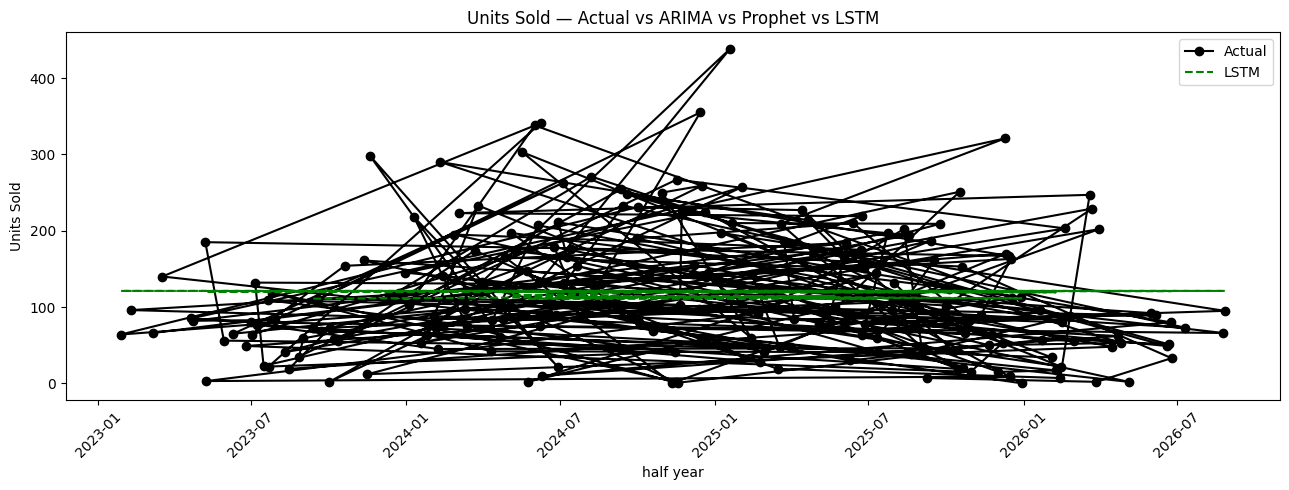

In [42]:
plt.figure(figsize=(13, 5))
#plt.plot(train.index[-20:], train.values[-20:], label="Train (recent)", color="gray")
plt.plot(test.index, test.values, label="Actual", color="black", marker="o")
#plt.plot(test.index, arima_pred, label="ARIMA", linestyle="--")
#plt.plot(test.index, prophet_pred, label="Prophet", linestyle="--")
plt.plot(test.index, lstm_pred, label="LSTM", color="green", linestyle="--")
plt.title("Units Sold — Actual vs ARIMA vs Prophet vs LSTM")
plt.xlabel("half year")
plt.ylabel("Units Sold")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Hyperparameter Tuning & Final Model

In [43]:
import itertools
import numpy as np
import pandas as pd
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sktime.performance_metrics.forecasting import (mean_absolute_percentage_error)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ==========================================
# 1. Clean NaN values and ensure correct types
# ==========================================
# Fill time-series lag/rolling NaNs before splitting
X = X.bfill().ffill()

# Dynamically select all categorical text columns to prevent passing raw strings into models
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=["number"]).columns.tolist()

# Robust preprocessor that explicitly handles unassigned text columns
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),cat_cols,)
    ],
    remainder="passthrough",
)

# Re-split cleaned data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 2. Hyperparameter Tuning Pipeline Setup
# ==========================================
if best_name == "Random Forest":
    tune_pipe = Pipeline(
        [("prep", preprocessor), ("model", RandomForestRegressor(random_state=42, n_jobs=-1))]
    )
    param_dist = {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
    }

elif best_name == "XGBoost":
    tune_pipe = Pipeline(
        [("prep", preprocessor), ("model", XGBRegressor(random_state=42, n_jobs=-1))]
    )
    param_dist = {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [3, 6, 9],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__subsample": [0.7, 0.8, 1.0],
    }

elif best_name == "LightGBM":
    tune_pipe = Pipeline(
        [("prep", preprocessor), ("model", LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1))]
   )
    param_dist = {
        "model__n_estimators": [100, 200, 300, 500],
        "model__max_depth": [3, 6, 8, -1],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__num_leaves": [15, 31, 63],
        "model__subsample": [0.7, 0.8, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 1.0],
    }

elif best_name == "Gradient Boosting":
    tune_pipe = Pipeline(
        [("prep", preprocessor), ("model", GradientBoostingRegressor(random_state=42))]
    )
    param_dist = {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [3, 4, 5],
        "model__learning_rate": [0.01, 0.05, 0.1],
    }

else:
    tune_pipe = None
    param_dist = None

# ==========================================
# 3. Fit Model with Debugging Enabled
# ==========================================
if tune_pipe is not None:
    # Use TimeSeriesSplit for cross-validation on temporal sequential data
    #tscv = TimeSeriesSplit(n_splits=3)

    search = RandomizedSearchCV(
        estimator=tune_pipe,
        param_distributions=param_dist,
        n_iter=5,
        #cv=tscv,
        scoring="r2",
        random_state=42,
        n_jobs=-1,
        error_score="raise",  # Will raise exact line error if fit fails
    )

    search.fit(X_train, y_train)

    print("Best params:", search.best_params_)
    best_model = search.best_estimator_
    pred = best_model.predict(X_test)

    # Output metrics
    print("Final Model:", best_name)
    print("Tuned MAE:", mean_absolute_error(y_test, pred))
    print("Tuned MSE:", mean_squared_error(y_test, pred))
    print("Tuned RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
    mask = y_test != 0
    mape = (np.mean(np.abs((y_test[mask] - pred[mask]) / y_test[mask])) * 100)
    print("Tuned MAPE:", mape)
    print("Tuned SMAPE:", mean_absolute_percentage_error(y_test, pred, symmetric=True))
    print("Tuned R2:", r2_score(y_test, pred))

    # Save the final model for later reuse
    joblib.dump(best_model, 'sales_forecast_model.pkl')
    print("Model saved as sales_forecast_model.pkl")

    # To reload later: best_model = joblib.load('sales_forecast_model.pkl')

Best params: {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 20}
Final Model: Random Forest
Tuned MAE: 4.204724720816878
Tuned MSE: 32.50325568817103
Tuned RMSE: 5.701162661086862
Tuned MAPE: 33.58577179231708
Tuned SMAPE: 0.29631673504574063
Tuned R2: 0.9629515871527525
Model saved as sales_forecast_model.pkl


Accuracy

In [44]:
import numpy as np

# Apply the Accuracy Formula: Accuracy (%) = 100% - MAPE (%)
# Max bound ensures accuracy doesn't go below 0% if MAPE exceeds 100%
model_accuracy = max(0.0, 100.0 - float(mape))

print(f"MAPE Error     : {mape:.2f}%")
print(f"Model Accuracy : {model_accuracy:.2f}%")

MAPE Error     : 33.59%
Model Accuracy : 66.41%


WMAPE (weighted MAPE): — This is the metric to use instead. It's the industry-standard alternative for exactly this situation (retail/sales data with frequent low or zero counts), computed as sum(|error|) / sum(|actual|) instead of averaging per-row percentages.

In [45]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
from sktime.performance_metrics.forecasting import (mean_absolute_percentage_error)

# WMAPE: robust to zero/near-zero actuals, unlike standard MAPE
def wmape(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)  # sales can't be negative
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

def wmape_scorer_func(y_true, y_pred):
    return -wmape(y_true, y_pred)  # negative so sklearn's "higher is better" still works

wmape_scorer = make_scorer(wmape_scorer_func, greater_is_better=True)

tune_pipe = Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(random_state=42, n_jobs=-1))])
param_dist = {
    'model__n_estimators': [200, 300, 500],
    'model__max_depth': [12, 20, None],
    'model__min_samples_leaf': [1, 2, 4],
}

search = RandomizedSearchCV(tune_pipe, param_dist, n_iter=10, cv=3, scoring=wmape_scorer, random_state=42, n_jobs=-1)
search.fit(X_train, y_train)

best_model = search.best_estimator_
pred = best_model.predict(X_test)

print("Best params:", search.best_params_)
print("Tune MAE:", (mean_absolute_error(y_test, pred)))
print("Tuned MSE:", (mean_squared_error(y_test, pred)))
print("Tuned RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("Tuned R2:", (r2_score(y_test, pred)))
print(f"Tuned WMAPE:", (wmape(y_test.values, pred)))
print("Tuned SMAPE:", mean_absolute_percentage_error(y_test, pred, symmetric=True))

Best params: {'model__n_estimators': 500, 'model__min_samples_leaf': 1, 'model__max_depth': 20}
Tune MAE: 4.191196855296765
Tuned MSE: 31.875667342567436
Tuned RMSE: 5.6458539958599205
Tuned R2: 0.963666935558128
Tuned WMAPE: 9.937286825668759
Tuned SMAPE: 0.2967715115685354


In [51]:
# Accuracy from WMAPE (analogous to your earlier "Accuracy = 1 - MAPE")

def wmape(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)  # sales can't be negative
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

pred = best_model.predict(X_test)
wmape_value = wmape(y_test.values, pred)
accuracy = 1 - (wmape_value / 100)   # as a fraction, e.g. 0.91

print(f"WMAPE:    {wmape_value:.2f}%")
print(f"Accuracy: {accuracy*100:.2f}%")

WMAPE:    9.94%
Accuracy: 90.06%


Generate Predictions & Package for Business Use

In [47]:
#Reusable prediction function
def predict_units_sold(new_data: pd.DataFrame, model_path='sales_forecast_model.pkl'):

    model = joblib.load(model_path)
    return model.predict(new_data)

# Quick sanity check on a few held-out rows
sample = X_test.iloc[:5]
print("Sample predictions:", predict_units_sold(sample))

Sample predictions: [50.15809524 38.17133333 37.68666667 59.30586081 27.62333333]


In [48]:
#Full test-set results table, with error column
test_results = X_test.copy()
test_results['Actual_Units_Sold'] = y_test.values
test_results['Predicted_Units_Sold'] = best_model.predict(X_test).round(1)
test_results['Abs_Error'] = (test_results['Actual_Units_Sold'] - test_results['Predicted_Units_Sold']).abs()

test_results.to_excel('sales_forecast_predictions.xlsx', index=False)
print("Saved: sales_forecast_predictions.xlsx —", test_results.shape)

Saved: sales_forecast_predictions.xlsx — (595, 46)


In [52]:
import joblib

# Save the exact trained model pipeline from your notebook
joblib.dump(rf_pipeline, "rf_model.joblib")

['rf_model.joblib']

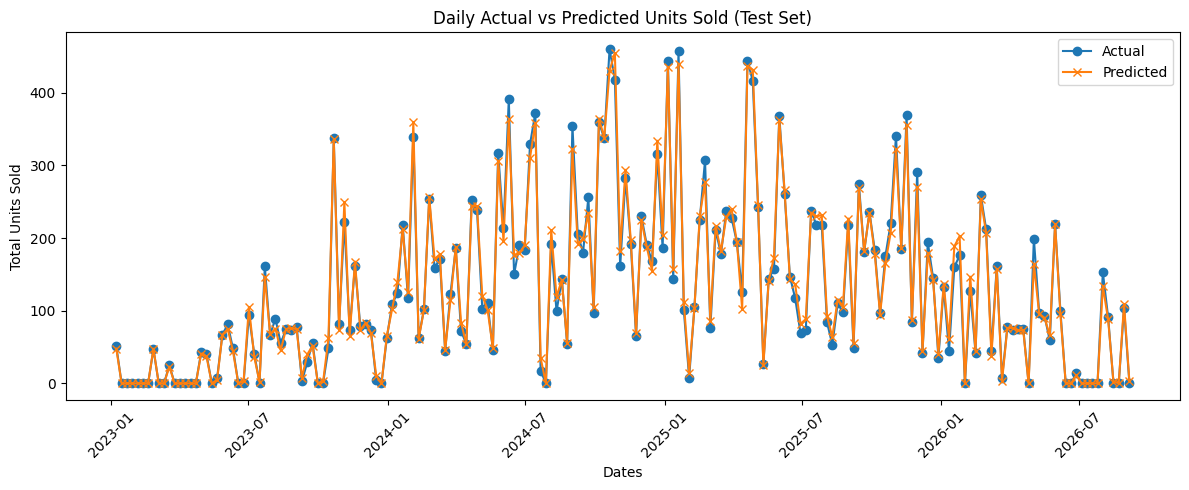

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
#Actual vs Predicted over time (weekly aggregate, for a trend chart)
dates_lookup = pd.read_excel('Sales_Forcasting_Dataset.xlsx')[['Date']].copy()
dates_lookup['Date'] = pd.to_datetime(dates_lookup['Date'])

comp = dates_lookup.loc[X_test.index, ['Date']].copy()
comp['Actual'] = y_test.values
comp['Predicted'] = best_model.predict(X_test)
comp = comp.sort_values('Date')

Daily = comp.set_index('Date').resample('W').sum(numeric_only=True)

plt.figure(figsize=(12, 5))
plt.plot(Daily.index, Daily['Actual'], label='Actual', marker='o')
plt.plot(Daily.index, Daily['Predicted'], label='Predicted', marker='x')
plt.title('Daily Actual vs Predicted Units Sold (Test Set)')
plt.xlabel('Dates')
plt.ylabel('Total Units Sold')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Download the files from Colab
#from google.colab import files
#files.download('sales_forecast_model.pkl')
#files.download('sales_forecast_predictions.xlsx')